

# K Nearest Neighbors 


In this project we are going explore the k nearest neighbors classification technique.

We are using a Melbourne housing data set, to predict the housing type as one of three possible categories:

  - 'h' house
  - 'u' duplex
  - 't' townhouse


In [1]:
# importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import calendar
%matplotlib inline

# Starting off loading a training set
df_melb = pd.read_csv('melb_data_train.csv')
df_melb

,Rooms,Type,Price,Date,Distance,Postcode,Bathroom,Car,Landsize,BuildingArea,YearBuilt
0,2,h,399000,7/5/16,8.7,3032,1,1.0,904,53.0,1985.0
1,3,h,1241000,28/08/2016,13.9,3165,1,1.0,643,NaN,NaN
2,2,u,550000,8/7/17,3.0,3067,1,1.0,1521,NaN,NaN
3,3,u,691000,24/06/2017,8.4,3072,1,1.0,170,NaN,NaN
4,2,u,657500,19/11/2016,4.6,3122,1,1.0,728,73.0,1965.0
...,...,...,...,...,...,...,...,...,...,...,...
495,2,t,710000,29/07/2017,7.2,3184,1,1.0,0,NaN,1980.0
496,2,u,446000,16/04/2016,8.0,3040,1,1.0,0,NaN,NaN
497,3,h,887000,8/4/17,9.2,3058,1,2.0,560,NaN,NaN
498,3,h,1365000,7/5/16,8.0,3040,1,1.0,754,NaN,NaN


## Fixing a column of data to be numeric
If we inspect our dataframe, `df_melb` using the `dtypes` method, we see that the column "Date" is an object. However, we think this column might contain useful information so we want to convert it to [seconds since epoch](https://en.wikipedia.org/wiki/Unix_time).

In [2]:
# normalize date accepts the date string as shown in the df_melb 'Date' column,
# and returns a data in a standarized format
def standardize_date(d):
    d = pd.to_datetime(d)
    return d.timestamp()

 Printing out the min and max epoch time to check our work.

In [3]:
df_melb['Date'] = df_melb['Date'].apply( lambda x : standardize_date(x))
df_melb['unixtime'] = df_melb['Date']
df_melb = df_melb.drop(columns='Date')

print("The min unixtime is {:f} and the max unixtime is {:f}".format(df_melb['unixtime'].min(),df_melb['unixtime'].max()))

The min unixtime is 1457481600.000000 and the max unixtime is 1512691200.000000


## Using Imputation to fill in missing values
kNN doesn't work when the attributes are not valid for all of the attribute columns, so we will fill in all the missing values in `df_melb` with the mean of that column. We will save the mean of each column in a dictionary, `dict_imputation`, whose key is the attribute column name, so we can apply the same imputation to the test set later. Show your `dict_imputation` dictionary and the head of your `df_melb` dataframe.  The target classfication is stored in the column `'Type'`, so we are going to define a variable target_col so we can reference the target_col using a variable. (hint: during imputation you skip the target column)

In [4]:
target_col = 'Type'

In [5]:
dict_imputation = dict()
for col in df_melb.columns:
    if col != target_col:
        dict_imputation[col] = df_melb[col].median()
        df_melb[col] = df_melb[col].fillna(dict_imputation[col])

In [6]:
dict_imputation

{'Rooms': 3.0,
 'Price': 801500.0,
 'Distance': 9.2,
 'Postcode': 3103.0,
 'Bathroom': 1.0,
 'Car': 1.0,
 'Landsize': 322.0,
 'BuildingArea': 109.0,
 'YearBuilt': 1970.0,
 'unixtime': 1488369600.0}

In [7]:
df_melb.head()

,Rooms,Type,Price,Distance,Postcode,Bathroom,Car,Landsize,BuildingArea,YearBuilt,unixtime
0,2,h,399000,8.7,3032,1,1.0,904,53.0,1985.0,1.467677e+09
1,3,h,1241000,13.9,3165,1,1.0,643,109.0,1970.0,1.472342e+09
2,2,u,550000,3.0,3067,1,1.0,1521,109.0,1970.0,1.502064e+09
3,3,u,691000,8.4,3072,1,1.0,170,109.0,1970.0,1.498262e+09
4,2,u,657500,4.6,3122,1,1.0,728,73.0,1965.0,1.479514e+09


## Normalizing all the attributes to be between [0,1]
Normalizing all the attribute columns in `df_melb` so they have a value between zero and one (inclusive). We will save the (min,max) tuple used to normalize to a dictionary, `dict_normalize`, so we can apply it to the test set later. The dataframe `df_melb` is now the "model" that we can use to classify new data points.

In [8]:
dict_normalize = dict()
for col in df_melb.columns:
    if col != target_col:
        dict_normalize[col] = (df_melb[col].min(), df_melb[col].max())
        df_melb[col] = (df_melb[col] - dict_normalize[col][0]) / (dict_normalize[col][1] - dict_normalize[col][0])

In [9]:
dict_normalize

{'Rooms': (1, 6),
 'Price': (291000, 5020000),
 'Distance': (0.7, 47.3),
 'Postcode': (3002, 3810),
 'Bathroom': (0, 4),
 'Car': (0.0, 4.0),
 'Landsize': (0, 41400),
 'BuildingArea': (0.0, 475.0),
 'YearBuilt': (1890.0, 2015.0),
 'unixtime': (1457481600.0, 1512691200.0)}

In [10]:
df_melb.head()

,Rooms,Type,Price,Distance,Postcode,Bathroom,Car,Landsize,BuildingArea,YearBuilt,unixtime
0,0.2,h,0.022838,0.171674,0.037129,0.25,0.25,0.021836,0.111579,0.76,0.184664
1,0.4,h,0.200888,0.283262,0.201733,0.25,0.25,0.015531,0.229474,0.64,0.269171
2,0.2,u,0.054768,0.049356,0.080446,0.25,0.25,0.036739,0.229474,0.64,0.807512
3,0.4,u,0.084584,0.165236,0.086634,0.25,0.25,0.004106,0.229474,0.64,0.738654
4,0.2,u,0.077501,0.083691,0.148515,0.25,0.25,0.017585,0.153684,0.60,0.399061


## Loading in the Test data and prep it for classification
Everything we did to our "train" set, we will now do in our "test" set. 

In [11]:
df_test = pd.read_csv("melb_data_test.csv")

In [12]:
df_test['Date'] = df_test['Date'].apply( lambda x : standardize_date(x))
df_test['unixtime'] = df_test['Date']

df_test = df_test.drop(columns='Date')

print("The min unixtime is {:f} and the max unixtime is {:f}".format(df_test['unixtime'].min(),df_test['unixtime'].max()))

The min unixtime is 1457481600.000000 and the max unixtime is 1512691200.000000


In [13]:
for col in df_test.columns:
    if col != target_col:
        df_test[col] = df_test[col].fillna(dict_imputation[col])

df_test.head()        

,Rooms,Type,Price,Distance,Postcode,Bathroom,Car,Landsize,BuildingArea,YearBuilt,unixtime
0,3,h,1116000,17.9,3192,1,2.0,610,109.0,1970.0,1.483747e+09
1,3,h,2030000,11.2,3186,2,2.0,366,109.0,1970.0,1.472342e+09
2,3,h,1480000,10.7,3187,2,2.0,697,143.0,1925.0,1.468195e+09
3,3,u,1203500,12.3,3166,2,2.0,311,127.0,2000.0,1.495843e+09
4,3,h,540000,14.7,3030,2,2.0,353,135.0,2011.0,1.489018e+09


In [14]:
for col in df_melb.columns:
    if col != target_col:
        df_test[col] = (df_test[col] - dict_normalize[col][0]) / (dict_normalize[col][1] - dict_normalize[col][0])
df_test.head()

,Rooms,Type,Price,Distance,Postcode,Bathroom,Car,Landsize,BuildingArea,YearBuilt,unixtime
0,0.4,h,0.174455,0.369099,0.235149,0.25,0.5,0.014734,0.229474,0.640,0.475743
1,0.4,h,0.367731,0.225322,0.227723,0.50,0.5,0.008841,0.229474,0.640,0.269171
2,0.4,h,0.251427,0.214592,0.228960,0.50,0.5,0.016836,0.301053,0.280,0.194053
3,0.4,u,0.192958,0.248927,0.202970,0.50,0.5,0.007512,0.267368,0.880,0.694836
4,0.4,h,0.052654,0.300429,0.034653,0.50,0.5,0.008527,0.284211,0.968,0.571205


## Writing the kNN classifier function
The function `knn_class`, takes five parameters, the training dataframe (that includes the target column), the hyper parameter `k`, the name of the target column, a single observation row (a series or attributes the same length as the attributes in `df_train`) of the test dataframe, and a boolean `use_weighted_vote`. When `use_weighted_vote` is set to true, we use weighted voting, otherwise we use majority voting. We are assuming that the parameter `df_train` contains all of the attributes, and the target class in the same dataframe. The function returns the predicted target classification for that observation. To find the distance between the single observation and the training data frame are using the [L2 norm](https://numpy.org/doc/stable/reference/generated/numpy.linalg.norm.html)

In [15]:
def knn_class(df_train, k, target_col, observation, use_weighted_vote ):
    df_train_copy = df_train.copy()
    df_train_target = df_train_copy[target_col]
    df_train_attributes = df_train_copy.copy()
    df_train_attributes = df_train_attributes.drop(columns=target_col)
    df_train_copy['d'] = (df_train_attributes - observation).apply(np.linalg.norm, axis = 1)
    
    if use_weighted_vote:
        df_train_copy['weight'] = (1/(df_train_copy['d'] * df_train_copy['d']))
        
        df_sorted_weight = df_train_copy.sort_values(by = 'weight')
        df_sorted_weight_reset = df_sorted_weight.copy()
        df_sorted_weight_reset = df_sorted_weight_reset.reset_index()
        
        df_weight_k = df_sorted_weight_reset[0:k] 
        predicted_target = df_weight_k[target_col].value_counts().index[0]

    else:
        df_sorted_maj = df_train_copy.sort_values(by = 'd')
        df_sorted_maj_reset = df_sorted_maj.copy()
        df_sorted_maj_reset = df_sorted_maj_reset.reset_index()
        
        df_maj_k = df_sorted_maj_reset[0:k]
        predicted_target = df_maj_k[target_col].value_counts().index[0]

    return predicted_target

## Computing the accuracy using different k values
For each value of $k$ in the set $\{1,3,13,25,50,100\}$ we calculate the class prediction for each oberservation in the test set, and the overall accuracy of the classifier. 

In [16]:
def accuracy(predicted, actual):
    accuracy = (predicted == actual).sum()/len(predicted)
    
    return accuracy

poss_k = [1,3,13,25,50,100] # possible k's
acc_k_majority = list(np.zeros(len(poss_k))) # Accuracy for each value of k using majority voting
acc_k_weighted = list(np.zeros(len(poss_k))) # Accuracy for each value of k using weighted voting

df_test_target = df_test[target_col]
df_test_attributes = df_test.drop(columns=target_col)

# majority
for i in range(len(poss_k)):
    predicted = df_test_attributes.apply(lambda row: knn_class(df_melb, poss_k[i], target_col, row, False), axis = 1)
    acc_majority = accuracy(predicted, df_test_target)
    acc_k_majority[i] = acc_majority
    
# weighted
for i in range(len(poss_k)):
    predicted = df_test_attributes.apply(lambda row: knn_class(df_melb, poss_k[i], target_col, row, True), axis = 1)
    
    acc_weight = accuracy(predicted, df_test_target)
    acc_k_weighted[i] = acc_weight

print(acc_k_majority)
print(acc_k_weighted)

[0.67, 0.67, 0.67, 0.69, 0.66, 0.67]
[0.67, 0.67, 0.63, 0.52, 0.46, 0.42]


 Plotting the accuracy as a function of $k$ when `use_weighted_vote` is `True` and when `use_weighted_vote` is `False`.

Text(0.5, 1.0, 'Accuracy using different k values')

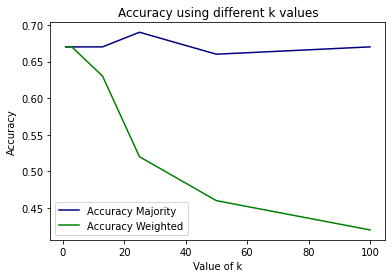

In [17]:
plt.plot(poss_k, acc_k_majority, color='navy')
plt.plot(poss_k, acc_k_weighted, color='green')
plt.legend(['Accuracy Majority', 'Accuracy Weighted'], loc='lower left')
plt.xlabel('Value of k')
plt.ylabel('Accuracy')
plt.title('Accuracy using different k values')

The highest accuracy for majority voting was 0.69 when k = 25, so this k value would be chosen to get the most accurate label prediction. The highest accuracy for majority voting was 0.67 when k = 1 and k = 13, so these k values would be chosen to get the most accurate label prediction. Overall, majority voting (with k = 25) should be used in order to get the highest possible accuracy for predicted labels. 